<a href="https://colab.research.google.com/github/aszczi/Urban_mobility_in_Cracow/blob/main/Mobilnosc_miejska_w_Krakowie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import time
import os

TOMTOM_API_KEY = "ZW0nhcWdTcUE6SJjSJV5f9vXyLKbBHuR"

POINTS = [
    {
        "name": "Rondo Mogilskie",
        "lat": 50.0672,
        "lon": 19.9595
    },
    {
        "name": "Lubomirskiego",
        "lat": 50.0676,
        "lon": 19.9536
    },
    {
        "name": "Aleja Powstania Warszawskiego",
        "lat": 50.0647,
        "lon": 19.9608
    },
    {
        "name": "Grzegórzecka",
        "lat": 50.0578,
        "lon": 19.9564
    },
    {
        "name": "Rondo Grzegórzeckie",
        "lat": 50.0576,
        "lon": 19.9609
    },
    {
        "name": "Galeria Krakowska / Pawia",
        "lat": 50.0669,
        "lon": 19.9457
    },
    {
        "name": "Dworzec Główny Tunel",
        "lat": 50.0686,
        "lon": 19.9477
    },
    {
        "name": "Aleje Trzech Wieszczów - AGH",
        "lat": 50.0674,
        "lon": 19.9209
    },
    {
        "name": "Plac Inwalidów",
        "lat": 50.0671,
        "lon": 19.9269
    },
    {
        "name": "Nowy Kleparz",
        "lat": 50.0731,
        "lon": 19.9352
    },
    {
        "name": "Aleja Słowackiego / Łobzowska",
        "lat": 50.0692,
        "lon": 19.9302
    },
    {
        "name": "Cracovia / Aleja Mickiewicza",
        "lat": 50.0595,
        "lon": 19.9235
    },
    {
        "name": "Rondo Grunwaldzkie",
        "lat": 50.0492,
        "lon": 19.9317
    },
    {
        "name": "Most Dębnicki",
        "lat": 50.0530,
        "lon": 19.9278
    },
    {
        "name": "Rondo Matecznego",
        "lat": 50.0364,
        "lon": 19.9406
    },
    {
        "name": "Kalwaryjska",
        "lat": 50.0412,
        "lon": 19.9443
    },
    {
        "name": "Bonarka / Kamieńskiego",
        "lat": 50.0298,
        "lon": 19.9513
    },
    {
        "name": "Zakopiańska / Brożka",
        "lat": 50.0227,
        "lon": 19.9349
    },
    {
        "name": "Łagiewniki",
        "lat": 50.0202,
        "lon": 19.9378
    },
    {
        "name": "Opolska Estakada",
        "lat": 50.0857,
        "lon": 19.9536
    },
    {
        "name": "Rondo Polsadu",
        "lat": 50.0879,
        "lon": 19.9618
    },
    {
        "name": "Rondo Barei",
        "lat": 50.0911,
        "lon": 19.9742
    },
    {
        "name": "Aleja 29 Listopada / Opolska",
        "lat": 50.0861,
        "lon": 19.9520
    },
    {
        "name": "Aleja 29 Listopada / Dobrego Pasterza",
        "lat": 50.0953,
        "lon": 19.9746
    },

    {
        "name": "Rondo Ofiar Katynia",
        "lat": 50.0879,
        "lon": 19.8976
    },
    {
        "name": "Bronowice SKA",
        "lat": 50.0814,
        "lon": 19.8994
    },
    {
        "name": "Armii Krajowej / Zarzecze",
        "lat": 50.0738,
        "lon": 19.8985
    },
    {
        "name": "Czarnowiejska / Armii Krajowej",
        "lat": 50.0690,
        "lon": 19.9075
    },

    {
        "name": "Rondo Czyżyńskie",
        "lat": 50.0729,
        "lon": 20.0167
    },
    {
        "name": "Plac Centralny",
        "lat": 50.0720,
        "lon": 20.0372
    },
    {
        "name": "Aleja Pokoju / Centralna",
        "lat": 50.0667,
        "lon": 20.0028
    },
    {
        "name": "Nowohucka / Klimeckiego",
        "lat": 50.0503,
        "lon": 19.9765
    },
    {
        "name": "M1 / Aleja Pokoju",
        "lat": 50.0661,
        "lon": 20.0149
    },

    {
        "name": "Wielicka / Powstańców Wielkopolskich",
        "lat": 50.0335,
        "lon": 19.9621
    },
    {
        "name": "Estakada Obrońców Lwowa",
        "lat": 50.0396,
        "lon": 19.9627
    },
    {
        "name": "Bieżanowska / Wielicka",
        "lat": 50.0207,
        "lon": 19.9820
    },
    {
        "name": "Prokocim Szpital",
        "lat": 50.0117,
        "lon": 20.0005
    },

    {
        "name": "Węzeł Łagiewniki",
        "lat": 50.0136,
        "lon": 19.9325
    },
    {
        "name": "Węzeł Balice / A4",
        "lat": 50.0878,
        "lon": 19.7937
    },
    {
        "name": "Węzeł Tyniec / A4",
        "lat": 50.0196,
        "lon": 19.8078
    },
    {
        "name": "Węzeł Wielicka / A4",
        "lat": 50.0034,
        "lon": 20.0065
    }
]

CSV_FILE = "traffic_history.csv"


def fetch_tomtom_flow(api_key, lat, lon):
    api_key = api_key.strip()

    if not api_key or api_key == "WKLEJ_TUTAJ_SWÓJ_KLUCZ":
        raise ValueError("Brak klucza TomTom. Wklej swój klucz do TOMTOM_API_KEY.")

    url = "https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/18/json"

    params = {
        "key": api_key,
        "point": f"{lat},{lon}",
        "unit": "kmph",
        "openLr": "false"
    }

    response = requests.get(url, params=params, timeout=15)

    if not response.ok:
        raise RuntimeError(
            f"TomTom HTTP {response.status_code}: {response.text[:300]}"
        )

    data = response.json()
    flow = data.get("flowSegmentData")

    if not flow:
        raise RuntimeError(f"Brak pola flowSegmentData w odpowiedzi: {data}")

    return flow


def collect_once():
    rows = []
    now = datetime.now()

    for point in POINTS:
        try:
            flow = fetch_tomtom_flow(
                TOMTOM_API_KEY,
                point["lat"],
                point["lon"]
            )

            current_speed = flow.get("currentSpeed")
            free_flow_speed = flow.get("freeFlowSpeed")
            current_travel_time = flow.get("currentTravelTime")
            free_flow_travel_time = flow.get("freeFlowTravelTime")
            confidence = flow.get("confidence")
            road_closure = flow.get("roadClosure")

            if current_travel_time is not None and free_flow_travel_time is not None:
                delay_sec = max(0, current_travel_time - free_flow_travel_time)
            else:
                delay_sec = None

            if current_speed is not None and free_flow_speed not in [None, 0]:
                speed_ratio = current_speed / free_flow_speed
                congestion_index = round((1 - speed_ratio) * 100, 2)
                congestion_index = max(0, congestion_index)
            else:
                speed_ratio = None
                congestion_index = None

            rows.append({
                "timestamp": now,
                "point_name": point["name"],
                "lat": point["lat"],
                "lon": point["lon"],
                "current_speed_kmph": current_speed,
                "free_flow_speed_kmph": free_flow_speed,
                "current_travel_time_sec": current_travel_time,
                "free_flow_travel_time_sec": free_flow_travel_time,
                "delay_sec": delay_sec,
                "speed_ratio": speed_ratio,
                "congestion_index_pct": congestion_index,
                "confidence": confidence,
                "road_closure": road_closure
            })

            print(
                f"{point['name']}: "
                f"{current_speed} km/h, "
                f"opóźnienie {delay_sec} s, "
                f"indeks korka {congestion_index}%"
            )

        except Exception as e:
            print(f"Błąd dla punktu {point['name']}: {e}")

    return pd.DataFrame(rows)


def save_to_csv(df):
    file_exists = os.path.exists(CSV_FILE)

    df.to_csv(
        CSV_FILE,
        mode="a",
        header=not file_exists,
        index=False,
        encoding="utf-8"
    )

    print(f"Zapisano {len(df)} rekordów do {CSV_FILE}")


def collect_loop(interval_minutes=5, number_of_rounds=12):
    """
    Przykład:
    interval_minutes=5, number_of_rounds=12
    oznacza zbieranie danych przez około godzinę.
    """
    for i in range(number_of_rounds):
        print(f"\n=== Pomiar {i + 1}/{number_of_rounds} ===")
        df = collect_once()

        if not df.empty:
            save_to_csv(df)

        if i < number_of_rounds - 1:
            time.sleep(interval_minutes * 60)


def load_history():
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"Nie ma jeszcze pliku {CSV_FILE}. Najpierw uruchom collect_loop()."
        )

    df = pd.read_csv(CSV_FILE)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    df["date"] = df["timestamp"].dt.date

    return df


def plot_delay_by_hour():
    df = load_history()

    hourly = (
        df.groupby(["hour", "point_name"])["delay_sec"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    for point_name in hourly["point_name"].unique():
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["delay_sec"],
            marker="o",
            label=point_name
        )

    plt.title("Średnie opóźnienie według godziny")
    plt.xlabel("Godzina")
    plt.ylabel("Średnie opóźnienie [s]")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_speed_by_hour():
    df = load_history()

    hourly = (
        df.groupby(["hour", "point_name"])["current_speed_kmph"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    for point_name in hourly["point_name"].unique():
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["current_speed_kmph"],
            marker="o",
            label=point_name
        )

    plt.title("Średnia aktualna prędkość według godziny")
    plt.xlabel("Godzina")
    plt.ylabel("Średnia prędkość [km/h]")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_congestion_index_by_hour():
    df = load_history()

    hourly = (
        df.groupby(["hour", "point_name"])["congestion_index_pct"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    for point_name in hourly["point_name"].unique():
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["congestion_index_pct"],
            marker="o",
            label=point_name
        )

    plt.title("Indeks zakorkowania według godziny")
    plt.xlabel("Godzina")
    plt.ylabel("Indeks zakorkowania [%]")
    plt.xticks(range(0, 24))
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_hourly_heatmap_table():
    """
    Prosta tabelka typu heatmapa bez seaborn.
    Pokazuje średni indeks zakorkowania:
    wiersze = punkty, kolumny = godziny.
    """
    df = load_history()

    pivot = df.pivot_table(
        index="point_name",
        columns="hour",
        values="congestion_index_pct",
        aggfunc="mean"
    )

    plt.figure(figsize=(14, 5))
    plt.imshow(pivot, aspect="auto")
    plt.colorbar(label="Indeks zakorkowania [%]")
    plt.title("Heatmapa korków według godziny i lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Lokalizacja")

    plt.xticks(
        ticks=range(len(pivot.columns)),
        labels=pivot.columns
    )
    plt.yticks(
        ticks=range(len(pivot.index)),
        labels=pivot.index
    )

    plt.tight_layout()
    plt.show()


def show_summary():
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            liczba_pomiarow=("timestamp", "count"),
            srednia_predkosc=("current_speed_kmph", "mean"),
            srednie_opoznienie_sec=("delay_sec", "mean"),
            max_opoznienie_sec=("delay_sec", "max"),
            sredni_indeks_korka_pct=("congestion_index_pct", "mean")
        )
        .round(2)
        .reset_index()
    )

    print(summary.to_string(index=False))

In [ ]:
collect_loop(interval_minutes=1, number_of_rounds=1)


=== Pomiar 1/1 ===
Rondo Mogilskie: 34 km/h, opóźnienie 0 s, indeks korka 0%
Lubomirskiego: 16 km/h, opóźnienie 0 s, indeks korka 0%
Aleja Powstania Warszawskiego: 31 km/h, opóźnienie 0 s, indeks korka 0%
Grzegórzecka: 29 km/h, opóźnienie 0 s, indeks korka 0%
Rondo Grzegórzeckie: 30 km/h, opóźnienie 0 s, indeks korka 0%
Galeria Krakowska / Pawia: 49 km/h, opóźnienie 0 s, indeks korka 0%
Dworzec Główny Tunel: 39 km/h, opóźnienie 0 s, indeks korka 0%
Aleje Trzech Wieszczów - AGH: 21 km/h, opóźnienie 0 s, indeks korka 0%
Plac Inwalidów: 16 km/h, opóźnienie 0 s, indeks korka 0%
Nowy Kleparz: 17 km/h, opóźnienie 21 s, indeks korka 32.0%
Aleja Słowackiego / Łobzowska: 27 km/h, opóźnienie 0 s, indeks korka 0%
Cracovia / Aleja Mickiewicza: 34 km/h, opóźnienie 0 s, indeks korka 0%
Rondo Grunwaldzkie: 17 km/h, opóźnienie 0 s, indeks korka 0%
Most Dębnicki: 28 km/h, opóźnienie 0 s, indeks korka 0%
Rondo Matecznego: 17 km/h, opóźnienie 3 s, indeks korka 29.17%
Kalwaryjska: 25 km/h, opóźnienie 0 s

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

CSV_FILE = "traffic_history.csv"


def load_history():
    if not os.path.exists(CSV_FILE):
        raise FileNotFoundError(
            f"Nie ma pliku {CSV_FILE}. Najpierw uruchom collect_loop()."
        )

    df = pd.read_csv(CSV_FILE)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["hour"] = df["timestamp"].dt.hour
    df["date"] = df["timestamp"].dt.date

    return df


def plot_current_congestion_ranking(top_n=20):

    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            avg_delay_sec=("delay_sec", "mean"),
            max_delay_sec=("delay_sec", "max"),
            avg_speed=("current_speed_kmph", "mean"),
            avg_congestion=("congestion_index_pct", "mean"),
            measurements=("timestamp", "count")
        )
        .reset_index()
        .sort_values("avg_delay_sec", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))

    plt.barh(
        summary["point_name"],
        summary["avg_delay_sec"]
    )

    plt.gca().invert_yaxis()
    plt.title(f"TOP {top_n} najbardziej zakorkowanych punktów")
    plt.xlabel("Średnie opóźnienie [s]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_speed_ranking(top_n=20):
    """
    Ranking miejsc z najniższą średnią prędkością.
    """
    df = load_history()

    summary = (
        df.groupby("point_name")
        .agg(
            avg_speed=("current_speed_kmph", "mean"),
            avg_delay_sec=("delay_sec", "mean"),
            avg_congestion=("congestion_index_pct", "mean"),
            measurements=("timestamp", "count")
        )
        .reset_index()
        .sort_values("avg_speed", ascending=True)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))

    plt.barh(
        summary["point_name"],
        summary["avg_speed"]
    )

    plt.gca().invert_yaxis()
    plt.title(f"TOP {top_n} punktów z najniższą średnią prędkością")
    plt.xlabel("Średnia prędkość [km/h]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_delay_by_hour_top(top_n=8):

    df = load_history()

    top_points = (
        df.groupby("point_name")["delay_sec"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    hourly = (
        filtered.groupby(["hour", "point_name"])["delay_sec"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 7))

    for point_name in top_points:
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["delay_sec"],
            marker="o",
            linewidth=2,
            label=point_name
        )

    plt.title(f"Średnie opóźnienie według godziny — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Średnie opóźnienie [s]")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Lokalizacja",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()


def plot_congestion_by_hour_top(top_n=8):
    """
    To samo, ale dla indeksu zakorkowania.
    """
    df = load_history()

    top_points = (
        df.groupby("point_name")["congestion_index_pct"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    hourly = (
        filtered.groupby(["hour", "point_name"])["congestion_index_pct"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(15, 7))

    for point_name in top_points:
        subset = hourly[hourly["point_name"] == point_name]
        plt.plot(
            subset["hour"],
            subset["congestion_index_pct"],
            marker="o",
            linewidth=2,
            label=point_name
        )

    plt.title(f"Indeks zakorkowania według godziny — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Indeks zakorkowania [%]")
    plt.xticks(range(0, 24))
    plt.grid(True, alpha=0.3)

    plt.legend(
        title="Lokalizacja",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()


def plot_delay_heatmap(top_n=25):

    df = load_history()

    top_points = (
        df.groupby("point_name")["delay_sec"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    filtered = df[df["point_name"].isin(top_points)]

    pivot = filtered.pivot_table(
        index="point_name",
        columns="hour",
        values="delay_sec",
        aggfunc="mean"
    )

    # sortowanie od najbardziej zakorkowanego punktu
    pivot["avg"] = pivot.mean(axis=1)
    pivot = pivot.sort_values("avg", ascending=False).drop(columns="avg")

    plt.figure(figsize=(16, max(7, top_n * 0.35)))

    plt.imshow(
        pivot,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label="Średnie opóźnienie [s]")
    plt.title(f"Heatmapa opóźnień — TOP {top_n} lokalizacji")
    plt.xlabel("Godzina")
    plt.ylabel("Lokalizacja")

    plt.xticks(
        ticks=range(len(pivot.columns)),
        labels=pivot.columns
    )

    plt.yticks(
        ticks=range(len(pivot.index)),
        labels=pivot.index
    )

    plt.tight_layout()
    plt.show()


def plot_latest_snapshot(top_n=20):

    df = load_history()

    latest_time = df["timestamp"].max()
    latest = df[df["timestamp"] == latest_time].copy()

    latest = latest.sort_values("delay_sec", ascending=False).head(top_n)

    plt.figure(figsize=(12, max(6, top_n * 0.35)))

    plt.barh(
        latest["point_name"],
        latest["delay_sec"]
    )

    plt.gca().invert_yaxis()
    plt.title(f"Najnowszy pomiar korków — {latest_time}")
    plt.xlabel("Opóźnienie [s]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()
def plot_average_speed_by_point(top_n=25):
    df = load_history()

    summary = (
        df.groupby("point_name")["current_speed_kmph"]
        .mean()
        .sort_values(ascending=True)
        .head(top_n)
    )

    plt.figure(figsize=(12, max(6, top_n * 0.35)))

    plt.barh(
        summary.index,
        summary.values
    )

    plt.gca().invert_yaxis()
    plt.title(f"Średnia prędkość — TOP {top_n} najwolniejszych lokalizacji")
    plt.xlabel("Średnia prędkość [km/h]")
    plt.ylabel("Lokalizacja")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

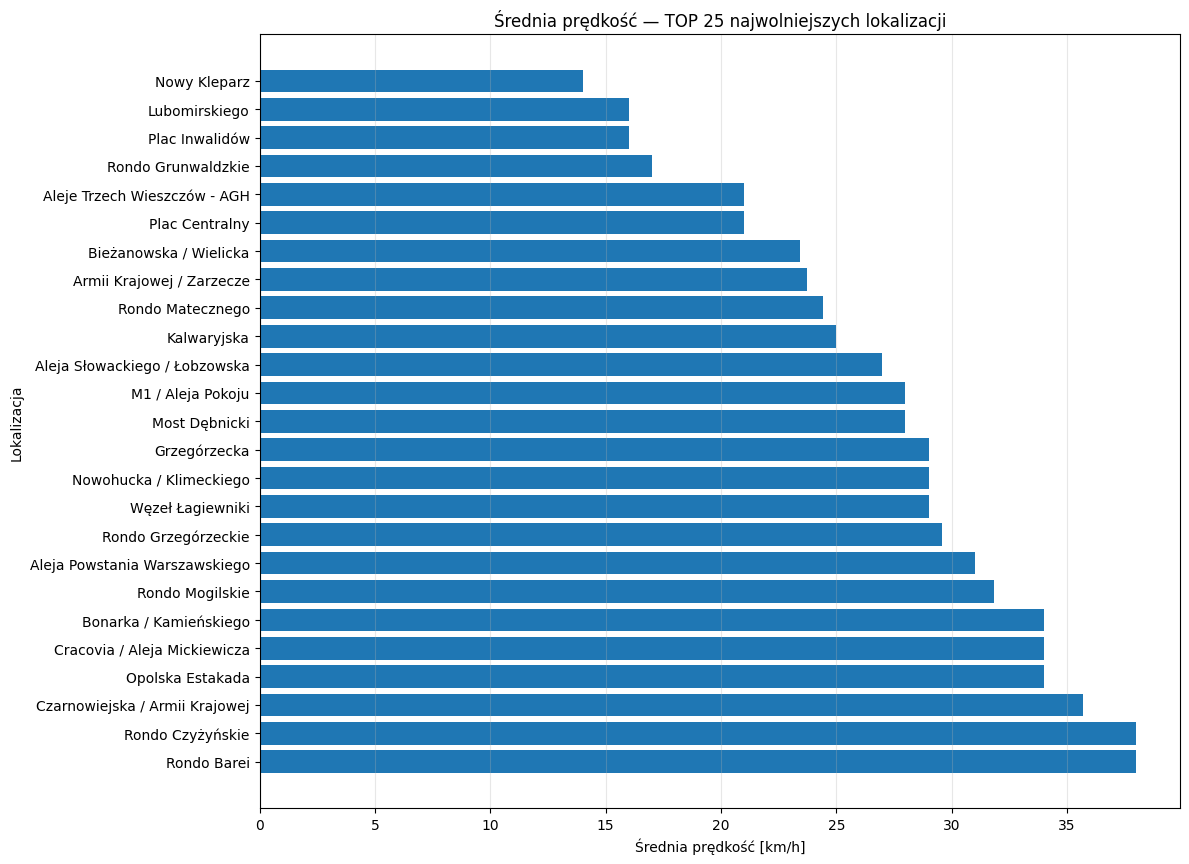

In [ ]:
plot_average_speed_by_point(top_n=25)

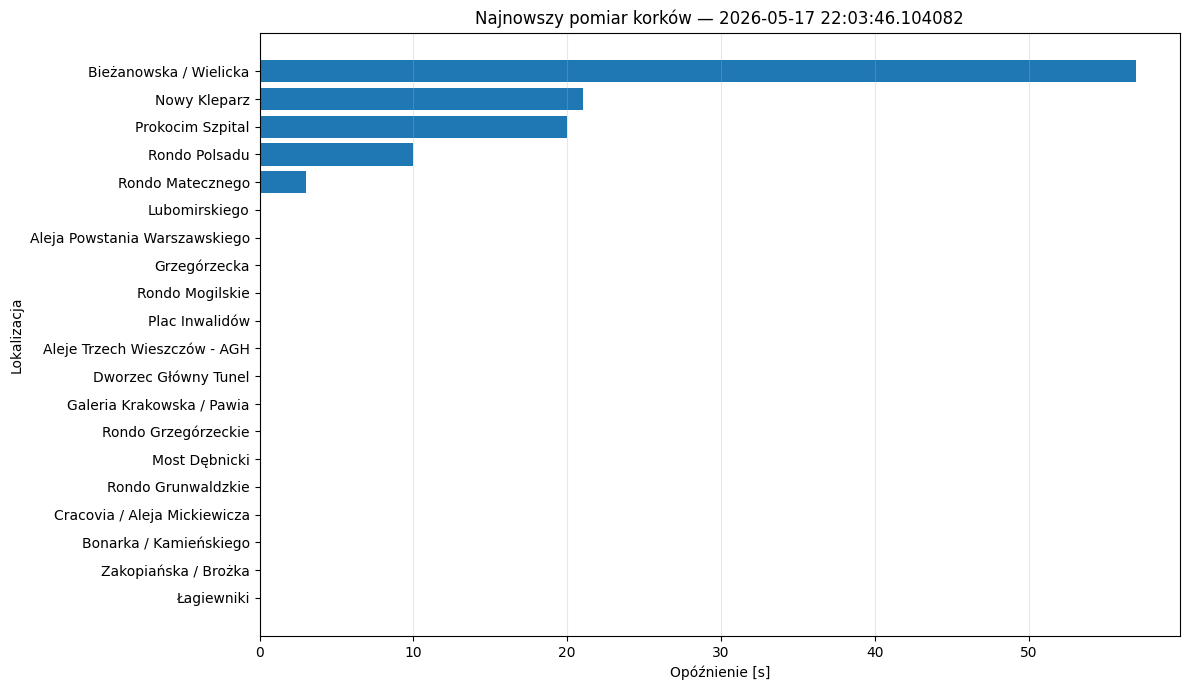

In [ ]:
plot_latest_snapshot(top_n=20)

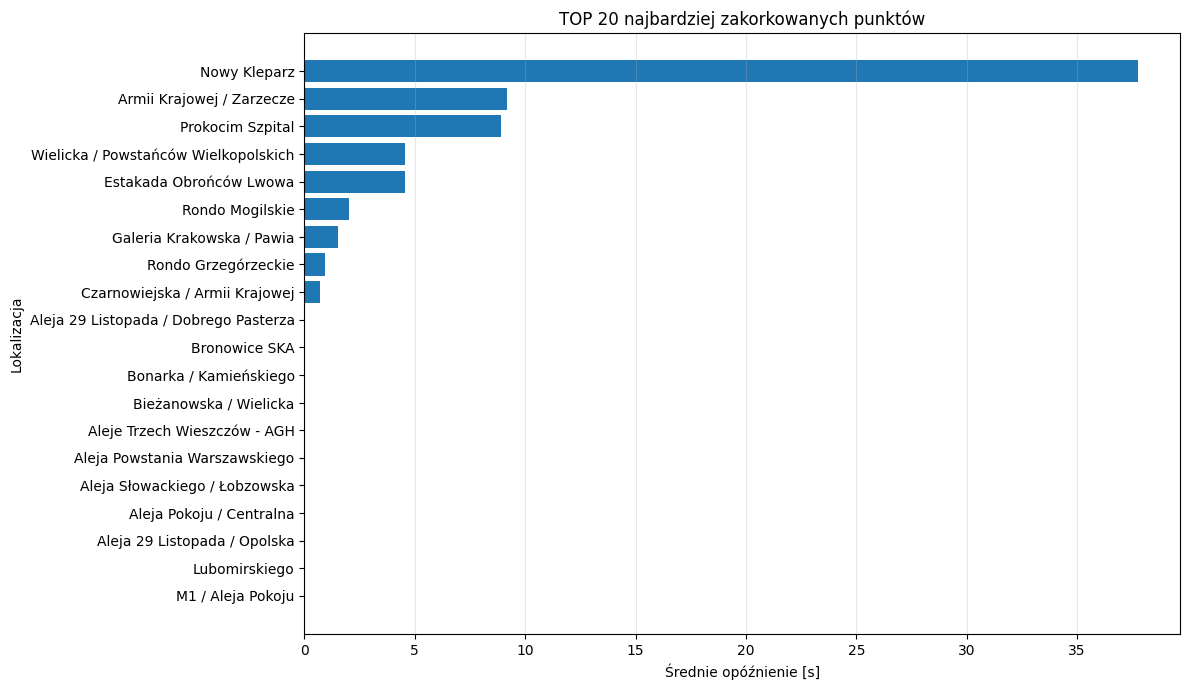

In [ ]:
plot_current_congestion_ranking(top_n=20)

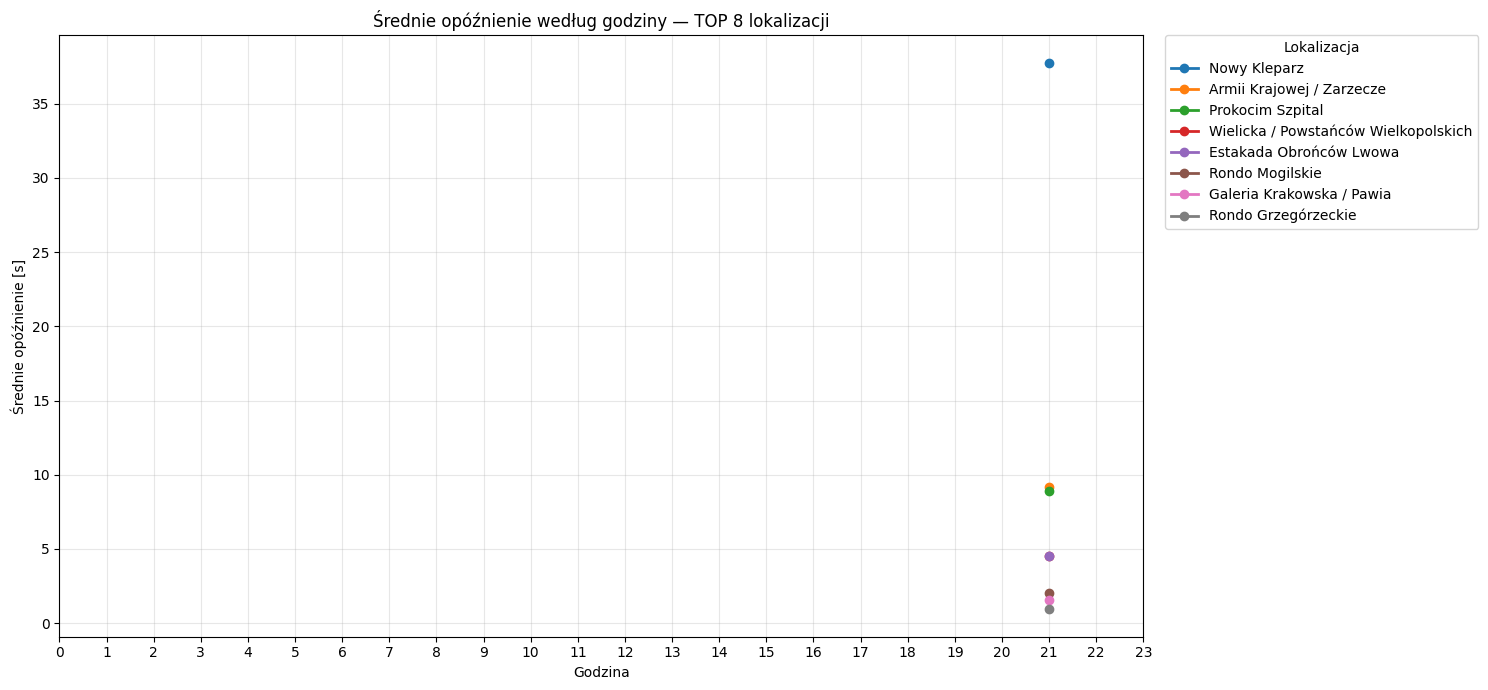

In [ ]:
plot_delay_by_hour_top(top_n=8)

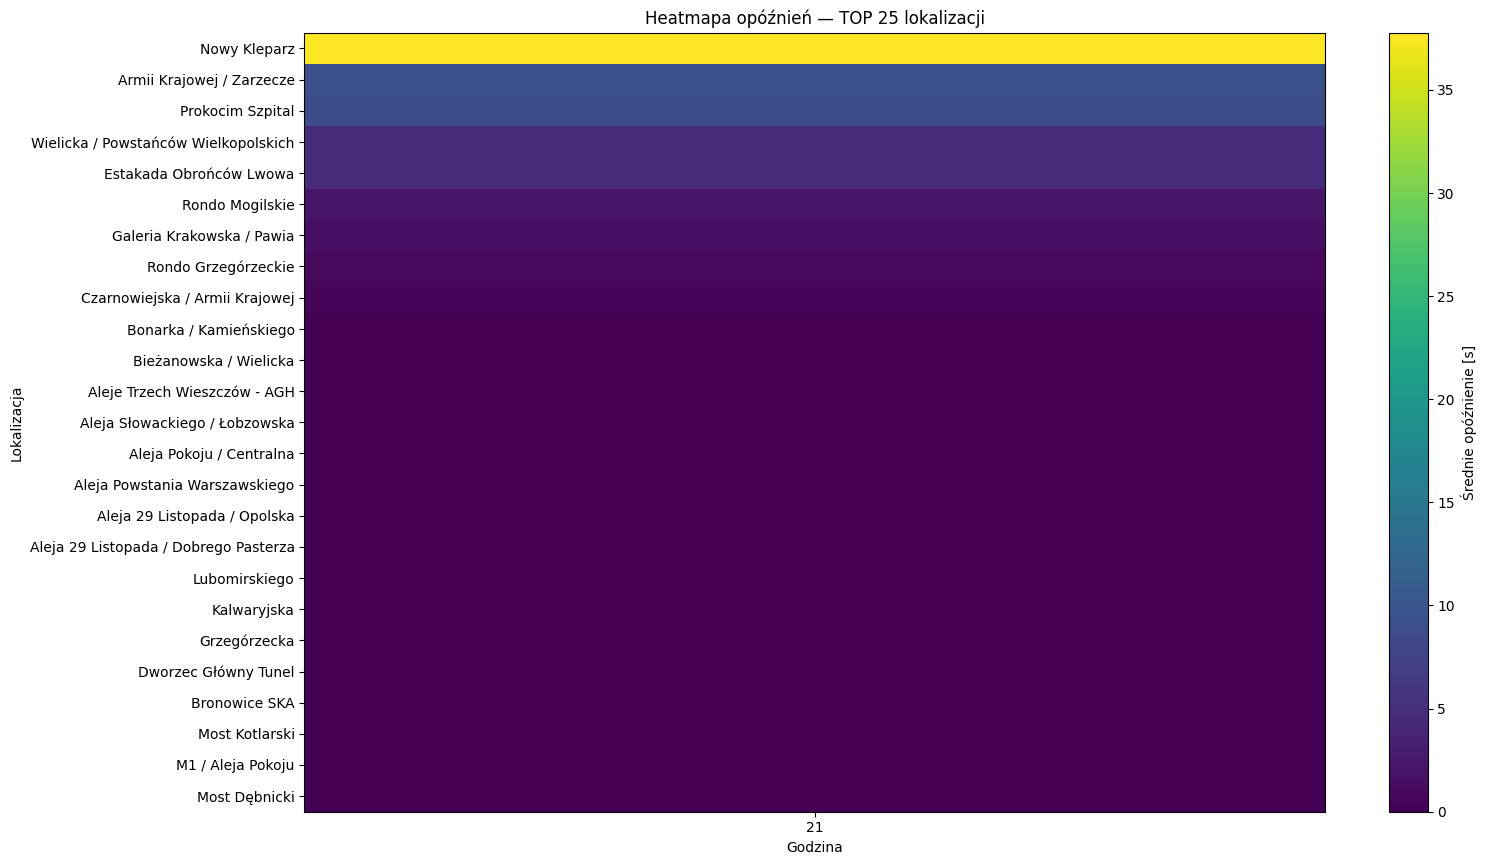

In [ ]:
plot_delay_heatmap(top_n=25)

In [ ]:
show_summary()

                           point_name  liczba_pomiarow  srednia_predkosc  srednie_opoznienie_sec  max_opoznienie_sec  sredni_indeks_korka_pct
Aleja 29 Listopada / Dobrego Pasterza               13             41.00                    0.00                   0                     0.00
         Aleja 29 Listopada / Opolska               13             56.00                    0.00                   0                     0.00
             Aleja Pokoju / Centralna               13             49.00                    0.00                   0                     0.00
        Aleja Powstania Warszawskiego               13             31.00                    0.00                   0                     0.00
        Aleja Słowackiego / Łobzowska               13             27.00                    0.00                   0                     0.00
         Aleje Trzech Wieszczów - AGH               13             21.00                    0.00                   0                     0.00
      

## Integracja Danych Przestrzennych

Poniżej przygotowano warstwy integrujące zebrane dane:
1. **Ścieżki rowerowe** (OSM GeoJSON)
2. **Pojazdy komunikacji miejskiej w czasie rzeczywistym** (TTSS JSON)
3. **Pomiary liczników rowerowych Eco-counter** (przykład z wprowadzonymi ręcznie uśrednionymi danymi)

In [ ]:
!pip install folium mapclassify geopandas pandas requests
import pandas as pd
import geopandas as gpd
import folium
import glob
import json
import os

print("Moduły załadowane! Gotowe do analizy krakowskich warstw GIS.")

In [ ]:
# 1. Wczytywanie Ścieżek Rowerowych (OSM)
osm_path = "data/OSM/krakow_bike_infrastructure.geojson"

try:
    gdf_bikes = gpd.read_file(osm_path)
    print(f"Pomyślnie wczytano geometrię dróg rowerowych. Obejmuje ona: {len(gdf_bikes)} segmentów.")
except Exception as e:
    print(f"Nie udało się załadować danych OSM: {e}")

# Wizualizacyjny wycinek tabeli:
if 'gdf_bikes' in locals():
    display(gdf_bikes[['highway', 'bicycle', 'geometry']].head(3))

In [ ]:
# 2. Przekształcenie Autobusów z TTSS w Geometrię GIS
ttss_files = glob.glob("data/TTSS/buses_*.json")

if ttss_files:
    latest_file = max(ttss_files, key=os.path.getctime)
    with open(latest_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    vehicles = data.get('vehicles', [])
    print(f"Pobrano {len(vehicles)} aktualnych pozycji autobusów.")
    
    # Tworzymy DataFrame, ignorujemy te bez lokalizacji
    df_buses = pd.DataFrame(vehicles)
    df_buses = df_buses.dropna(subset=['latitude', 'longitude'])
    
    # Transformacja punktów do GeoDataFrame
    gdf_buses = gpd.GeoDataFrame(
        df_buses, 
        geometry=gpd.points_from_xy(df_buses['longitude'] / 3600000.0, df_buses['latitude'] / 3600000.0),
        crs="EPSG:4326"
    )
else:
    print("Brak danych o autobusach w TTSS.")
    gdf_buses = gpd.GeoDataFrame()
    
if not gdf_buses.empty:
    display(gdf_buses[['name', 'category', 'geometry']].head(3))

In [ ]:
# 3. Zintegrowane Liczniki ZTP (Eco-Counter) - próbka danych zebranych na podstawie logów IFRAME:
# Przykład mapuje identyfikator licznika do jego lokalizacji GPS oraz sumarycznego wyniku próbnego
eco_counters_data = [
    {"counter_id": "100034393", "name": "Kotlarski - ruch rowerowy", "lat": 50.0558, "lon": 19.9614, "daily_volume": 412},
    {"counter_id": "300062594", "name": "Bulwary (Wawel)", "lat": 50.0520, "lon": 19.9328, "daily_volume": 1250},
    {"counter_id": "100045859", "name": "Bora-Komorowskiego", "lat": 50.0827, "lon": 19.9868, "daily_volume": 845},
    {"counter_id": "300014608", "name": "Armii Krajowej / Bronowice", "lat": 50.0763, "lon": 19.8972, "daily_volume": 320}
]

df_eco = pd.DataFrame(eco_counters_data)
gdf_eco = gpd.GeoDataFrame(
    df_eco, 
    geometry=gpd.points_from_xy(df_eco['lon'], df_eco['lat']),
    crs="EPSG:4326"
)

display(gdf_eco)

In [ ]:
# 4. Globalna Wizualizacja Warstw Mobilnych
# Ustalamy środek mapy na Rynek Główny
map_krakow = folium.Map(location=[50.0614, 19.9365], zoom_start=13, tiles="CartoDB positron")

# A. Dodajemy infrastrukturę rowerową
if 'gdf_bikes' in locals():
    # Rysujemy tylko 2000 segmentów aby sprzęt nie wysiadł przy podglądzie
    folium.GeoJson(
        gdf_bikes.head(2000), 
        name="Ścieżki rowerowe (OSM)",
        style_function=lambda x: {'color': '#118C4F', 'weight': 2, 'opacity': 0.6}
    ).add_to(map_krakow)

# B. Dodajemy punkty liczników (Eco-Counter)
for idx, row in gdf_eco.iterrows():
    folium.CircleMarker(
        location=[row['geometry'].y, row['geometry'].x],
        radius=8,
        popup=f"<strong>{row['name']}</strong><br>Dzisiejszy ruch: {row['daily_volume']}",
        tooltip=row['name'],
        color="orange",
        fill=True,
        fill_color="red"
    ).add_to(map_krakow)

# C. Dodajemy pozycje autobusów!
if 'gdf_buses' in locals() and not gdf_buses.empty:
    for idx, row in gdf_buses.iterrows():
        # Kolorystyka np. niebieska - autobusy
        bus_name = row.get('name', 'Autobus')
        folium.CircleMarker(
            location=[row['geometry'].y, row['geometry'].x],
            radius=4,
            popup=f"Linia: {bus_name}",
            tooltip=bus_name,
            color="blue",
            fill=True,
            fill_color="blue"
        ).add_to(map_krakow)

folium.LayerControl().add_to(map_krakow)

# Wyświetlanie
map_krakow